In [1]:
import os
import polars as pl
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

data_dir = '/Users/IvanTang/hep/data_Run502/simulation/'
clusters_df = pl.read_parquet(os.path.join(data_dir, "sim_clusters.parquet"))
tracks_df = pl.read_parquet(os.path.join(data_dir, "sim_tracks.parquet"))
print(clusters_df)
print(tracks_df)

shape: (3_034_976, 12)
┌─────────┬──────────┬──────────┬────────────┬───┬──────┬──────────┬───────────┬───────────────┐
│ node_id ┆ event_id ┆ layer_id ┆ x_trk_mm   ┆ … ┆ size ┆ track_id ┆ is_signal ┆ particle_type │
│ ---     ┆ ---      ┆ ---      ┆ ---        ┆   ┆ ---  ┆ ---      ┆ ---       ┆ ---           │
│ u32     ┆ i64      ┆ i64      ┆ f64        ┆   ┆ i64  ┆ i64      ┆ bool      ┆ str           │
╞═════════╪══════════╪══════════╪════════════╪═══╪══════╪══════════╪═══════════╪═══════════════╡
│ 0       ┆ 0        ┆ 0        ┆ 14.6015    ┆ … ┆ 2    ┆ -1       ┆ false     ┆ background    │
│ 1       ┆ 0        ┆ 0        ┆ -9.3815    ┆ … ┆ 1    ┆ -1       ┆ false     ┆ background    │
│ 2       ┆ 0        ┆ 0        ┆ -4.2485    ┆ … ┆ 1    ┆ -1       ┆ false     ┆ background    │
│ 3       ┆ 0        ┆ 0        ┆ 12.1365    ┆ … ┆ 1    ┆ -1       ┆ false     ┆ background    │
│ 4       ┆ 0        ┆ 0        ┆ -1.135833  ┆ … ┆ 3    ┆ -1       ┆ false     ┆ background    │
│ …    

In [2]:
from src.utils import build_labeled_edges_from_sim, edge_label_stats
edges_df = build_labeled_edges_from_sim(clusters_df)
print(edge_label_stats(edges_df))


{'n_total': 2356820, 'n_positive': 504, 'n_negative': 2356316, 'positive_fraction': 0.00021384747244167988, 'n_signal_edges': 504, 'signal_fraction_of_pos': 1.0}


In [9]:
print(edges_df.sort(by=pl.col('event_id')))
print(edges_df.columns)


shape: (2_356_820, 27)
┌──────────┬──────────┬──────────┬───────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ event_id ┆ src_node ┆ dst_node ┆ src_layer ┆ … ┆ track_id_i ┆ track_id_j ┆ edge_labe ┆ is_signal │
│ ---      ┆ ---      ┆ ---      ┆ ---       ┆   ┆ ---        ┆ ---        ┆ l         ┆ _edge     │
│ i64      ┆ i64      ┆ i64      ┆ i64       ┆   ┆ i64        ┆ i64        ┆ ---       ┆ ---       │
│          ┆          ┆          ┆           ┆   ┆            ┆            ┆ i64       ┆ i64       │
╞══════════╪══════════╪══════════╪═══════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 0        ┆ 0        ┆ 605      ┆ 0         ┆ … ┆ -1         ┆ -1         ┆ 0         ┆ 0         │
│ 0        ┆ 0        ┆ 677      ┆ 0         ┆ … ┆ -1         ┆ -1         ┆ 0         ┆ 0         │
│ 0        ┆ 2        ┆ 915      ┆ 0         ┆ … ┆ -1         ┆ -1         ┆ 0         ┆ 0         │
│ 0        ┆ 3        ┆ 628      ┆ 0         ┆ … ┆ -1         ┆ -1  

In [4]:
import importlib, torch, numpy as np
import torch.optim as optim
from sklearn.metrics import roc_auc_score, average_precision_score
import src.models as M
importlib.reload(M)
from src.models import event_to_tensors, EdgeMLP, InteractionNet, FocalLoss

# ── train / val split on event_id ──────────────────────────────────────────
all_events = np.array(edges_df["event_id"].unique().sort().to_numpy(), copy=True)
rng = np.random.default_rng(42)
rng.shuffle(all_events)
n_train = int(len(all_events) * 0.8)
train_events = set(all_events[:n_train].tolist())
val_events   = set(all_events[n_train:].tolist())

train_df = edges_df.filter(pl.col("event_id").is_in(list(train_events)))
val_df   = edges_df.filter(pl.col("event_id").is_in(list(val_events)))

print(f"Events  train={len(train_events)}  val={len(val_events)}")
print(f"Edges   train={len(train_df):,}    val={len(val_df):,}")
print(f"Pos     train={int(train_df['edge_label'].sum())}   val={int(val_df['edge_label'].sum())}")


Events  train=800  val=200
Edges   train=1,884,239    val=472,581
Pos     train=392   val=112


In [5]:
from src.models import NODE_FEAT_COLS_SRC, EDGE_FEAT_COLS

# ── compute normalisation stats from training edges ────────────────────────
_node_src = train_df.select(NODE_FEAT_COLS_SRC).to_numpy(allow_copy=True).astype(np.float32)
_edge_f   = train_df.select(EDGE_FEAT_COLS).to_numpy(allow_copy=True).astype(np.float32)

NODE_MEAN = torch.tensor(_node_src.mean(0), dtype=torch.float32)
NODE_STD  = torch.tensor(_node_src.std(0).clip(1e-6), dtype=torch.float32)
EDGE_MEAN = torch.tensor(_edge_f.mean(0), dtype=torch.float32)
EDGE_STD  = torch.tensor(_edge_f.std(0).clip(1e-6), dtype=torch.float32)

def normalise(node_feat, edge_feat):
    return (node_feat - NODE_MEAN) / NODE_STD, (edge_feat - EDGE_MEAN) / EDGE_STD

print("Node feat means:", NODE_MEAN.numpy().round(3))
print("Edge feat means:", EDGE_MEAN.numpy().round(3))


Node feat means: [ 1.466 -1.675 -0.629 29.313  1.603  1.659  2.493]
Edge feat means: [-5.00e-03 -0.00e+00  2.00e+01  3.06e-01 -0.00e+00 -0.00e+00]


In [6]:
DEVICE = torch.device('mps')
print("Device:", DEVICE)

# ── choose model: "mlp" or "gnn" ──────────────────────────────────────────
MODEL_TYPE = "gnn"

#model = EdgeMLP(hidden=64).to(DEVICE)
model = InteractionNet(hidden=64, n_mp=2).to(DEVICE)

criterion = FocalLoss(alpha=0.995, gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)

print(f"Model: {MODEL_TYPE}  params={sum(p.numel() for p in model.parameters()):,}")

# ── training loop (per-event graphs) ──────────────────────────────────────
N_EPOCHS = 20

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    train_loss = 0.0
    n_batches  = 0

    for eid, ev_df in train_df.group_by("event_id"):
        nf, ei, ef, lab, _ = event_to_tensors(ev_df)
        if lab.sum() == 0:        # skip zero-positive events
            continue

        nf, ef = (nf, ef)
        nf  = nf.to(DEVICE)
        ei  = ei.to(DEVICE)
        ef  = ef.to(DEVICE)
        lab = lab.to(DEVICE)

        optimizer.zero_grad()
        pred = model(nf, ei, ef)
        loss = criterion(pred, lab)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()
        n_batches  += 1

    scheduler.step()

    # ── validation (AUC) every 5 epochs ───────────────────────────────────
    if epoch % 5 == 0 or epoch == 1:
        model.eval()
        all_scores, all_labels = [], []
        with torch.no_grad():
            for _, ev_df in val_df.group_by("event_id"):
                nf, ei, ef, lab, _ = event_to_tensors(ev_df)
                nf, ef = normalise(nf, ef)
                scores = model(nf.to(DEVICE), ei.to(DEVICE), ef.to(DEVICE)).cpu().numpy()
                all_scores.append(scores)
                all_labels.append(lab.numpy())

        y_score = np.concatenate(all_scores)
        y_true  = np.concatenate(all_labels)
        auc  = roc_auc_score(y_true, y_score)
        ap   = average_precision_score(y_true, y_score)
        avg_loss = train_loss / max(n_batches, 1)
        print(f"Epoch {epoch:>3} | loss={avg_loss:.4f} | val AUC={auc:.4f} | AP={ap:.4f}")


Device: mps


Device: mps


/opt/anaconda3/envs/e320root/lib/python3.12/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,


Device: mps


/opt/anaconda3/envs/e320root/lib/python3.12/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,


...

Device: mps


/opt/anaconda3/envs/e320root/lib/python3.12/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,


Model: gnn  params=80,449


/Users/IvanTang/hep/E320simulator/src/models.py:99: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226120/work/torch/csrc/utils/tensor_numpy.cpp:212.)
  torch.from_numpy(nid_arr),                               # (N,)


Epoch   1 | loss=0.0008 | val AUC=0.8323 | AP=0.0015
Epoch   5 | loss=0.0005 | val AUC=0.8711 | AP=0.0023
Epoch  10 | loss=0.0004 | val AUC=0.8761 | AP=0.0032
Epoch  15 | loss=0.0002 | val AUC=0.8712 | AP=0.0044
Epoch  20 | loss=0.0002 | val AUC=0.8654 | AP=0.0040


Val edges: 472,581  positives: 112
ROC-AUC : 0.8654
Avg Prec: 0.0040


Val edges: 472,581  positives: 112
ROC-AUC : 0.8654
Avg Prec: 0.0040


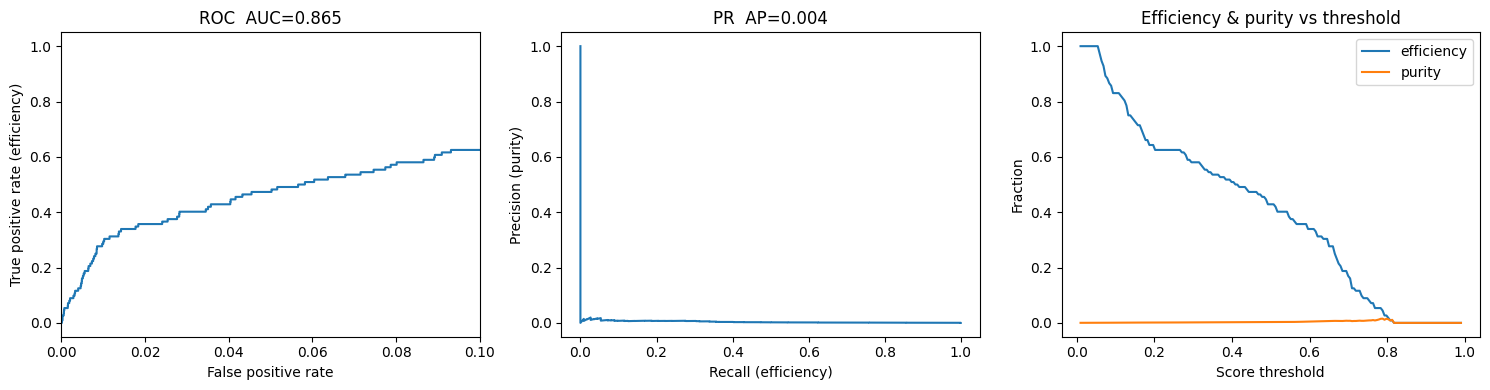

Val edges: 472,581  positives: 112
ROC-AUC : 0.8654
Avg Prec: 0.0040


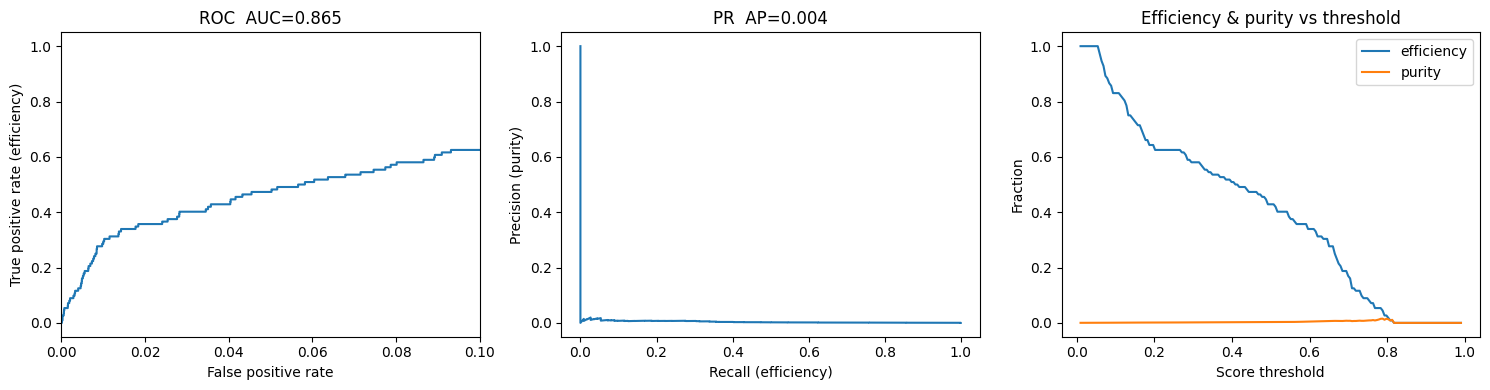

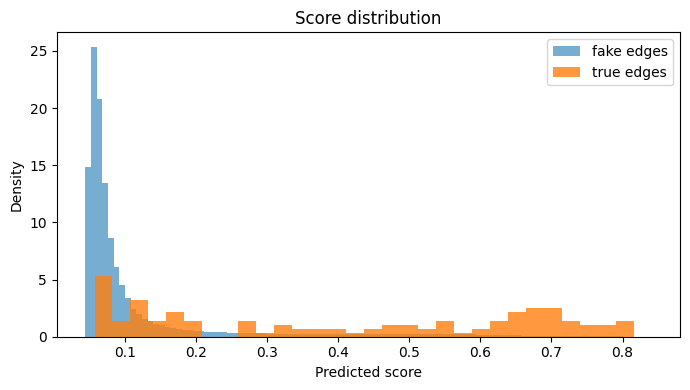

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# ── collect full val predictions ───────────────────────────────────────────
model.eval()
all_scores, all_labels = [], []
with torch.no_grad():
    for _, ev_df in val_df.group_by("event_id"):
        nf, ei, ef, lab, _ = event_to_tensors(ev_df)
        nf, ef = normalise(nf, ef)
        scores = model(nf.to(DEVICE), ei.to(DEVICE), ef.to(DEVICE)).cpu().numpy()
        all_scores.append(scores)
        all_labels.append(lab.numpy())

y_score = np.concatenate(all_scores)
y_true  = np.concatenate(all_labels)

print(f"Val edges: {len(y_true):,}  positives: {int(y_true.sum())}")
print(f"ROC-AUC : {roc_auc_score(y_true, y_score):.4f}")
print(f"Avg Prec: {average_precision_score(y_true, y_score):.4f}")

# ── threshold sweep: efficiency vs graph purity ────────────────────────────
thresholds = np.linspace(0.01, 0.99, 200)
efficiencies, purities = [], []
for t in thresholds:
    keep  = y_score >= t
    tp    = (keep & (y_true == 1)).sum()
    fp    = (keep & (y_true == 0)).sum()
    fn    = (~keep & (y_true == 1)).sum()
    eff   = tp / (tp + fn + 1e-9)
    pur   = tp / (tp + fp + 1e-9)
    efficiencies.append(eff)
    purities.append(pur)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
axes[0].plot(fpr, tpr)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate (efficiency)")
axes[0].set_title(f"ROC  AUC={roc_auc_score(y_true, y_score):.3f}")
axes[0].set_xlim(0, 0.1)   # zoom into low-FPR region

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_true, y_score)
axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall (efficiency)")
axes[1].set_ylabel("Precision (purity)")
axes[1].set_title(f"PR  AP={average_precision_score(y_true, y_score):.3f}")

# Efficiency vs Purity vs threshold
axes[2].plot(thresholds, efficiencies, label="efficiency")
axes[2].plot(thresholds, purities,     label="purity")
axes[2].set_xlabel("Score threshold")
axes[2].set_ylabel("Fraction")
axes[2].set_title("Efficiency & purity vs threshold")
axes[2].legend()

plt.tight_layout()
plt.show()

# ── score distribution ─────────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_score[y_true == 0], bins=100, alpha=0.6, density=True, label="fake edges")
ax.hist(y_score[y_true == 1], bins=30,  alpha=0.8, density=True, label="true edges")
ax.set_xlabel("Predicted score")
ax.set_ylabel("Density")
ax.set_title("Score distribution")
ax.legend()
plt.tight_layout()
plt.show()
